In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_openml
from sklearn.decomposition import PCA

### Load Dataset

In [35]:
iris = load_iris()
X = iris.data[:, :3]
y = iris.target
print(X.shape)

(150, 3)


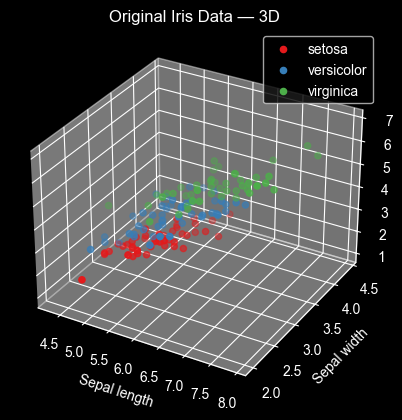

In [36]:
fig = plt.figure()
colors = ["#E41A1C", "#377EB8", "#4DAF4A"]  # red, blue, green
ax = fig.add_subplot(111, projection="3d")
for i, name in enumerate(iris.target_names):
    mask = y == i
    ax.scatter(X[mask, 0], X[mask, 1], X[mask, 2], label=name, color=colors[i])

ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")
ax.set_zlabel("Petal length")
ax.set_title("Original Iris Data — 3D")
ax.legend()
plt.show()

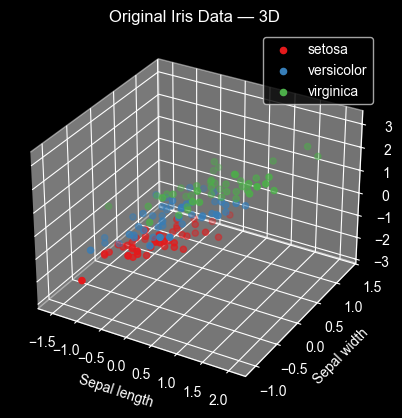

In [37]:
X_centered = X - X.mean(axis=0)

fig = plt.figure()
colors = ["#E41A1C", "#377EB8", "#4DAF4A"]  # red, blue, green
ax = fig.add_subplot(111, projection="3d")
for i, name in enumerate(iris.target_names):
    mask = y == i
    ax.scatter(X_centered[mask, 0], X_centered[mask, 1], X_centered[mask, 2], label=name, color=colors[i])

ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")
ax.set_zlabel("Petal length")
ax.set_title("Original Iris Data — 3D")
ax.legend()
plt.show()

### PCA

In [38]:
pca = PCA(n_components=3)
pca.fit(X)

print("PC1:", pca.components_[0])
print("PC2:", pca.components_[1])

PC1: [ 0.38983343 -0.09100801  0.91637735]
PC2: [ 0.63922328  0.74305866 -0.19813487]


In [39]:
W2 = pca.components_.T
W2

array([[ 0.38983343,  0.63922328, -0.66289026],
       [-0.09100801,  0.74305866,  0.66300933],
       [ 0.91637735, -0.19813487,  0.34784355]])

In [40]:
X_reduced = pca.transform(X)
print(X_reduced.shape)

(150, 3)


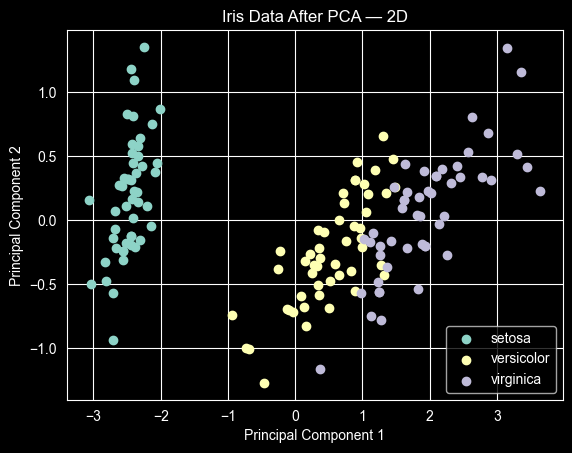

In [41]:
plt.figure()
for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X_reduced[mask, 0], X_reduced[mask, 1], label=name)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Data After PCA — 2D")
plt.legend()
plt.show()

### Measures

In [42]:
pca.explained_variance_ratio_

array([0.92464061, 0.06046599, 0.0148934 ])

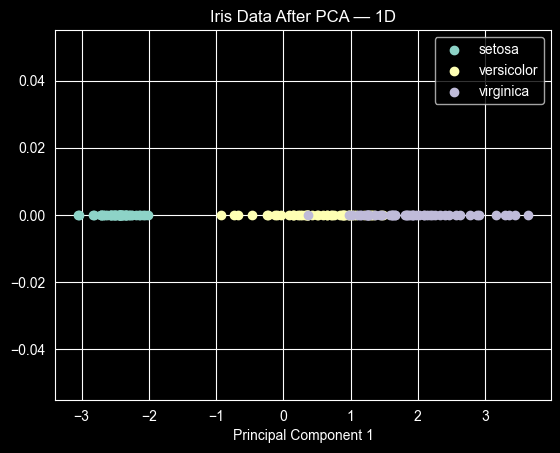

In [43]:
plt.figure()
for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X_reduced[mask, 0],[0]*len(X_reduced[mask, 0]), label=name)

plt.xlabel("Principal Component 1")
plt.title("Iris Data After PCA — 1D")
plt.legend()
plt.show()

### From 4D to 2D

In [48]:
iris = load_iris()
X = iris.data[:, :]
y = iris.target
pca = PCA(n_components=2)
pca.fit(X)
pca.components_.T

array([[ 0.36138659,  0.65658877],
       [-0.08452251,  0.73016143],
       [ 0.85667061, -0.17337266],
       [ 0.3582892 , -0.07548102]])

In [49]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

(150, 2)


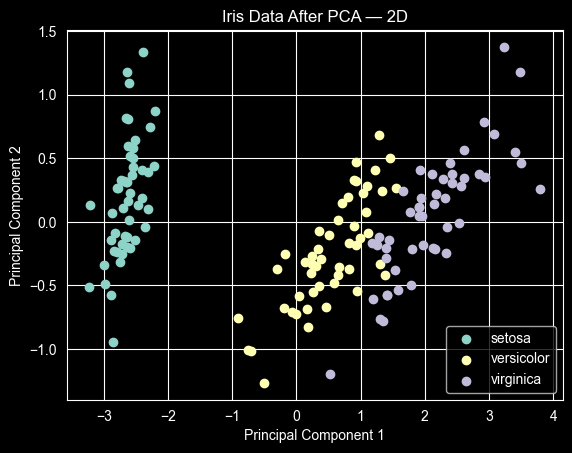

In [51]:
X_reduced = pca.transform(X)
print(X_reduced.shape)
plt.figure()
for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X_reduced[mask, 0], X_reduced[mask, 1], label=name)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Data After PCA — 2D")
plt.legend()
plt.show()

end